In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
model_path = '/content/drive/MyDrive/Colab Notebooks/Hw/my_models_13'
os.makedirs(model_path, exist_ok=True)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
fashion_mnist = keras.datasets.fashion_mnist

In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.0

class_names = ["Футболка", "Штани", "Пуловер", "Сукня", "Пальто",
               "Сандалі", "Сорочка", "Кросівки", "Сумка", "Черевики"]

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (55000, 28, 28)
X_test: (10000, 28, 28)


In [ ]:
X_train_cnn = X_train[..., tf.newaxis]
X_valid_cnn = X_valid[..., tf.newaxis]
X_test_cnn = X_test[..., tf.newaxis]

In [ ]:
model_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 469,098 (1.79 MB)

 Trainable params: 468,458 (1.79 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_valid_cnn, y_valid),
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8341 - loss: 0.4769 - val_accuracy: 0.8988 - val_loss: 0.2764 - learning_rate: 0.0010
Epoch 2/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8923 - loss: 0.3065 - val_accuracy: 0.9138 - val_loss: 0.2409 - learning_rate: 0.0010
Epoch 3/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9060 - loss: 0.2639 - val_accuracy: 0.9176 - val_loss: 0.2254 - learning_rate: 0.0010
Epoch 4/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9131 - loss: 0.2420 - val_accuracy: 0.9242 - val_loss: 0.2077 - learning_rate: 0.0010
Epoch 5/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9170 - loss: 0.2302 - val_accuracy: 0.9214 - val_loss: 0.2127 - learning_rate: 0.0010
Epoch 6/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9231 - loss: 0.2156 - val_accuracy: 0.9238 - val_loss: 0.2016 - learning_rate: 0.0010
Epoch 7/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9269 - loss: 0.2034

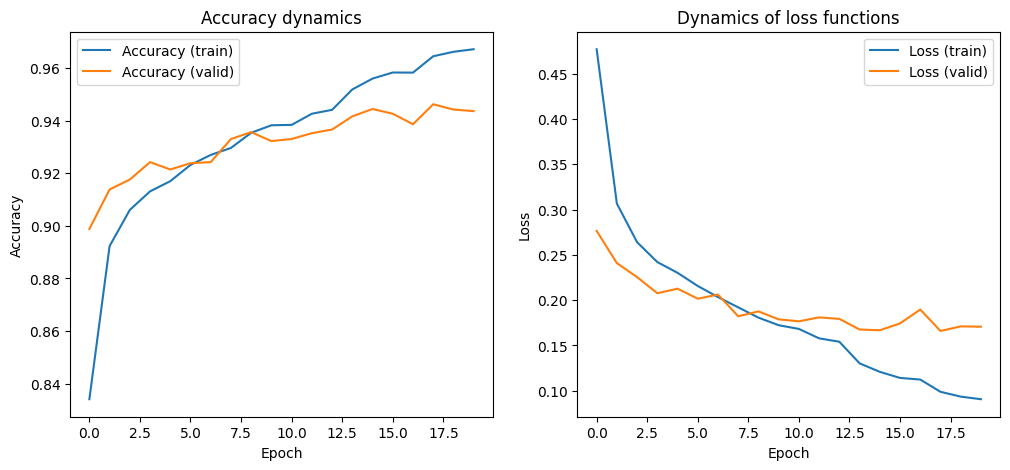

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Accuracy (train)')
plt.plot(history_cnn.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Loss (train)')
plt.plot(history_cnn.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [ ]:
test_loss, test_accuracy = model_cnn.evaluate(X_test_cnn, y_test)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9385 - loss: 0.1880
Test accuracy: 94%
Test loss: 0.1880


In [ ]:
X_train_vgg = np.repeat(X_train[..., np.newaxis], 3, axis=-1)
X_valid_vgg = np.repeat(X_valid[..., np.newaxis], 3, axis=-1)
X_test_vgg = np.repeat(X_test[..., np.newaxis], 3, axis=-1)

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

base_model.trainable = False

model_vgg = models.Sequential([
    layers.Input(shape=(28, 28, 3)),
    layers.Resizing(32, 32),
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model_vgg.fit(
    X_train_vgg, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_valid_vgg, y_valid)
)

Epoch 1/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.6119 - loss: 1.1708 - val_accuracy: 0.7838 - val_loss: 0.6700
Epoch 2/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.7599 - loss: 0.7004 - val_accuracy: 0.8128 - val_loss: 0.5584
Epoch 3/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.7861 - loss: 0.6105 - val_accuracy: 0.8236 - val_loss: 0.5073
Epoch 4/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8025 - loss: 0.5612 - val_accuracy: 0.8328 - val_loss: 0.4758
Epoch 5/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8130 - loss: 0.5313 - val_accuracy: 0.8424 - val_loss: 0.4528


In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_vgg = model_vgg.fit(
    X_train_vgg, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_valid_vgg, y_valid),
    callbacks=[early_stopping]
)

Epoch 1/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.8493 - loss: 0.4135 - val_accuracy: 0.8764 - val_loss: 0.3359
Epoch 2/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8808 - loss: 0.3298 - val_accuracy: 0.8928 - val_loss: 0.3005
Epoch 3/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8940 - loss: 0.2942 - val_accuracy: 0.9000 - val_loss: 0.2778
Epoch 4/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9038 - loss: 0.2668 - val_accuracy: 0.8928 - val_loss: 0.2789
Epoch 5/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9111 - loss: 0.2459 - val_accuracy: 0.9030 - val_loss: 0.2675
Epoch 6/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9167 - loss: 0.2305 - val_accuracy: 0.9068 - val_loss: 0.2622
Epoch 7/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9217 - loss: 0.2160 - val_accuracy: 0.9102 - val_loss: 0.2569
Epoch 8/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9265 - loss: 0.2026 - 

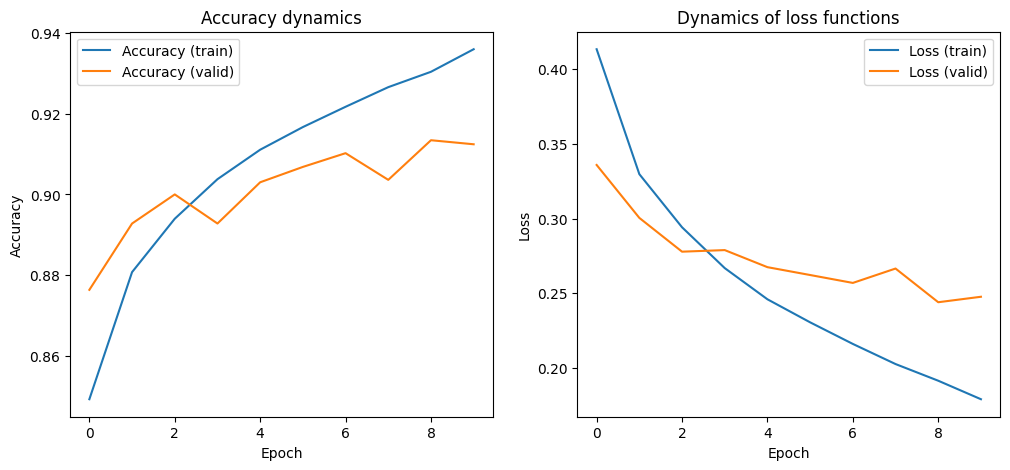

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Accuracy (train)')
plt.plot(history_vgg.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Loss (train)')
plt.plot(history_vgg.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [ ]:
test_loss, test_accuracy = model_vgg.evaluate(X_test_vgg, y_test)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9057 - loss: 0.2625
Test accuracy: 91%
Test loss: 0.2625


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


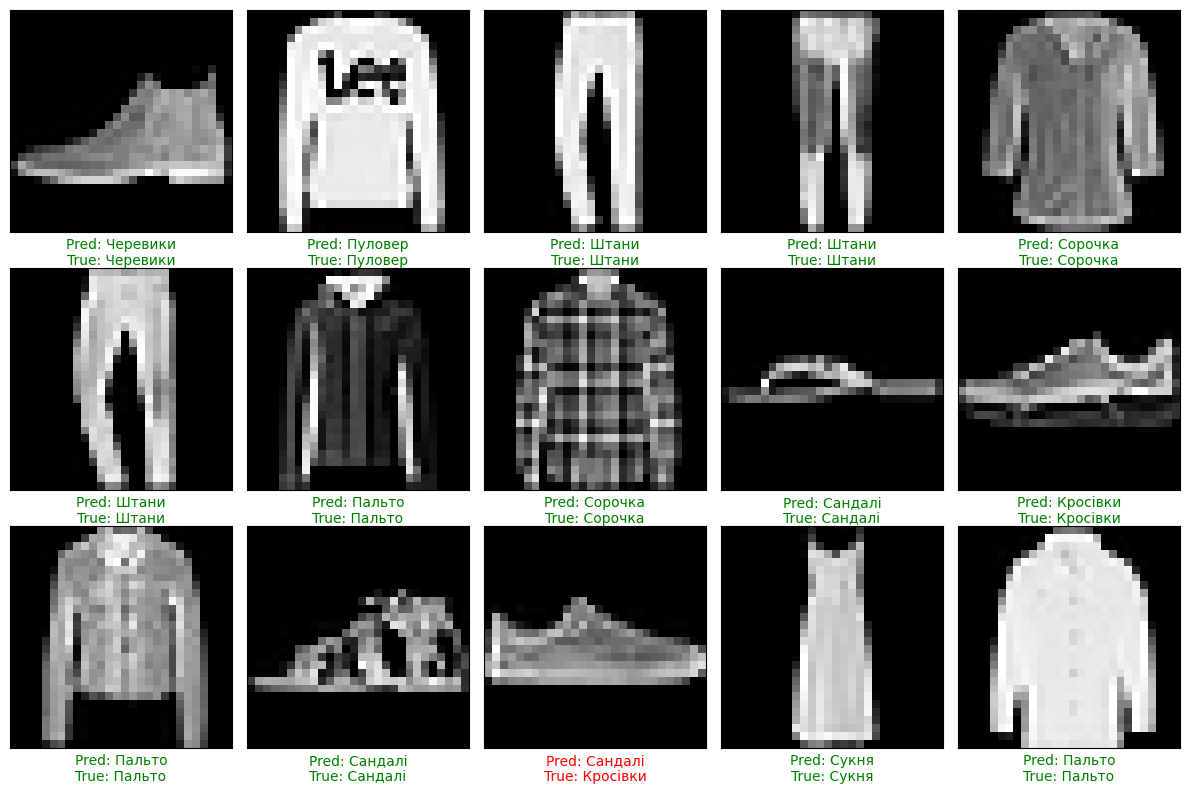

In [ ]:
predictions = model_vgg.predict(X_test_vgg)

plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(X_test_vgg[i].reshape(28, 28, 3), cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i] if y_test.ndim == 1 else np.argmax(y_test[i])

    color = "green" if predicted_label == true_label else "red"

    plt.xlabel(
        f"Pred: {class_names[predicted_label]}\nTrue: {class_names[true_label]}",
        color=color,
        fontsize=10,
    )

plt.tight_layout()
plt.show()

In [ ]:
model_cnn.save(f'{model_path}/model_cnn.keras')
model_vgg.save(f'{model_path}/model_vgg.keras')

In [ ]:
model_cnn = load_model(f'{model_path}/model_cnn.keras')

In [ ]:
model_vgg = load_model(f'{model_path}/model_vgg.keras')

In [ ]:
def save_training_plots(history, model_name):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{model_name} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{model_path}/{model_name}_metrics.png')
    plt.close()

In [ ]:
save_training_plots(history_cnn, 'cnn')

In [ ]:
save_training_plots(history_vgg, 'vgg')

In [ ]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image, ImageOps
import os

CLASS_NAMES = ["Футболка", "Штани", "Пуловер", "Сукня", "Пальто",
               "Сандалі", "Сорочка", "Кросівки", "Сумка", "Черевики"]

st.title("Neural Network Visualization App")
st.write("Upload an image to classify it using one of the trained models.")

model_option = st.sidebar.selectbox(
    'Select a model for classification:',
    ('Convolutional Neural Network', 'VGG-based Model')
)

if model_option == 'Convolutional Neural Network':
    model_path_keras = 'model_cnn.keras'
    metrics_path = 'cnn_metrics.png'
else:
    model_path_keras = 'model_vgg.keras'
    metrics_path = 'vgg_metrics.png'

@st.cache_resource
def load_cached_model(model_path):
    if not os.path.exists(model_path):
        return None
    return tf.keras.models.load_model(model_path)

st.subheader("Model Training Metrics")
if os.path.exists(metrics_path):
    st.image(metrics_path, use_container_width=True)
else:
    st.warning(f"Metrics plot not found at: {metrics_path}")

invert_colors = st.sidebar.checkbox("Invert image colors (recommended for dark clothing on white background)", value=True)

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image', width=300)

    if st.button("Classify Image"):
        with st.spinner("Loading model and predicting... This may take a few seconds."):
            try:
                model = load_cached_model(model_path_keras)
                
                if model is None:
                    st.error(f"Model file not found at: {model_path_keras}. Please check your files.")
                else:
                    input_shape = model.input_shape[1:3]

                    if model_option == 'Convolutional Neural Network':
                        img_processed = image.convert('L')
                        
                        if invert_colors:
                            img_processed = ImageOps.invert(img_processed)
                            
                        img_resized = img_processed.resize(input_shape)
                        img_array = np.array(img_resized)
                        
                        img_array = np.expand_dims(img_array, axis=-1)
                        img_array = img_array.astype('float32') / 255.0
                        
                    else:
                        img_processed = image.convert('RGB')
                        
                        if invert_colors:
                            img_processed = ImageOps.invert(img_processed)
                            
                        img_resized = img_processed.resize(input_shape)
                        img_array = np.array(img_resized)
                        
                        img_array = tf.keras.applications.vgg16.preprocess_input(img_array)

                    img_array = np.expand_dims(img_array, axis=0)

                    predictions = model.predict(img_array)[0]
                    predicted_class_idx = np.argmax(predictions)
                    predicted_class = CLASS_NAMES[predicted_class_idx]

                    st.success(f"**Predicted Class:** {predicted_class}")

                    st.subheader("Class Probabilities:")
                    for i, prob in enumerate(predictions):
                        class_name = CLASS_NAMES[i] if i < len(CLASS_NAMES) else f"Class {i}"
                        st.write(f"- **{class_name}**: {prob*100:.2f}%")
                        st.progress(float(prob))

            except Exception as e:
                st.error(f"Error during classification: {str(e)}")


Overwriting app.py


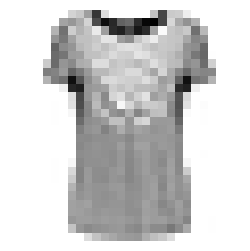

Class: Футболка


In [ ]:
index = 1

plt.figure(figsize=(3, 3))
plt.imshow(X_train[index], cmap="binary")
plt.axis('off')

plt.show()

print(f"Class: {class_names[y_train[index]]}")